# Satellite Image Classification


In [19]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset

import torchvision
from torchvision import transforms, datasets, models

from collections import defaultdict
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")


reproducibility()

Random seed set to 42


## 0: Dataset and Preprocessing


In [4]:
base_transform = transforms.Compose([transforms.ToTensor()])

eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=base_transform)

100%|██████████| 94.3M/94.3M [00:00<00:00, 247MB/s] 


In [13]:
num_images = len(eurosat_data)
class_names = eurosat_data.classes
num_classes = len(eurosat_data.classes)
img_shape = eurosat_data[0][0].shape

print(f"Total images: {num_images}")
print(f"Total classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Image shape: {img_shape}")

Total images: 27000
Total classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape: torch.Size([3, 64, 64])


In [14]:
train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [18]:
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(eurosat_data):
    class_indices[label].append(idx)

train_full_idx = []
train_10shot_idx = []
train_5shot_idx = []
val_idx = []
test_idx = []

for label, indices in class_indices.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices = indices[:n_train]
    val_indices = indices[n_train : n_train + n_val]
    test_indices = indices[n_train + n_val :]
    train_full_idx.extend(train_indices)
    val_idx.extend(val_indices)
    test_idx.extend(test_indices)
    train_10shot_idx.extend(train_indices[:10])
    train_5shot_idx.extend(train_indices[:5])

train_full = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_full_idx,
)
train_10shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_10shot_idx,
)
train_5shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_5shot_idx,
)
val_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    val_idx,
)
test_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    test_idx,
)

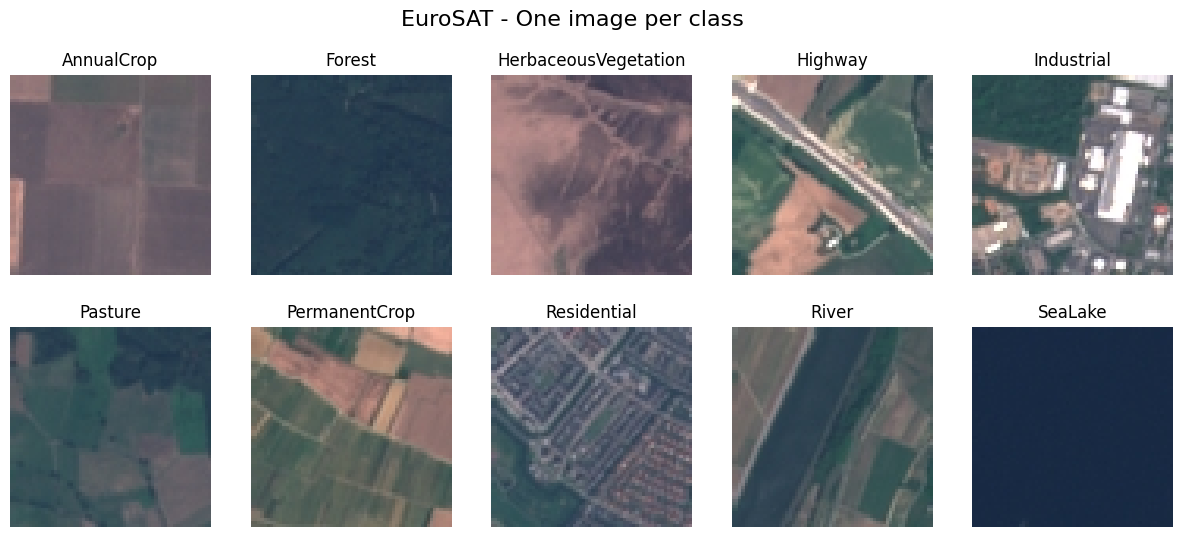

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls in range(num_classes):
    for img, label in eurosat_data:
        if label == cls:
            axes[cls].imshow(img.permute(1, 2, 0))
            axes[cls].set_title(class_names[cls])
            axes[cls].axis("off")
            break

plt.suptitle("EuroSAT - One image per class", fontsize=16)
plt.show()

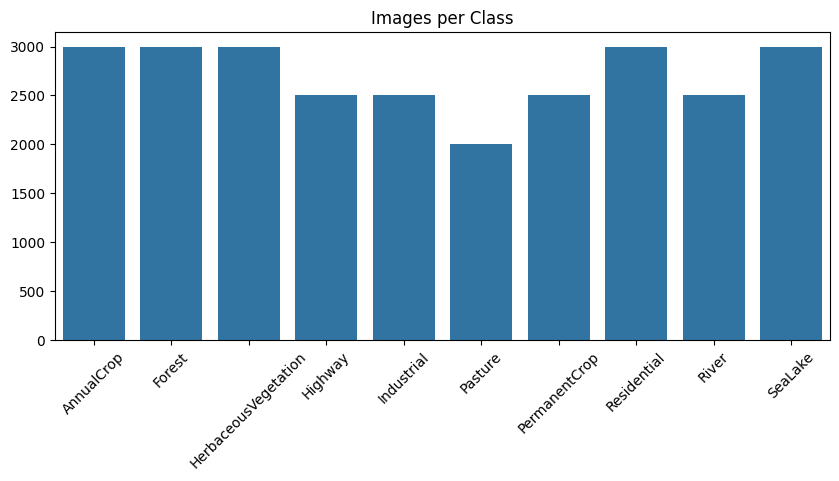

In [20]:
counts = [len(class_indices[c]) for c in range(num_classes)]
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

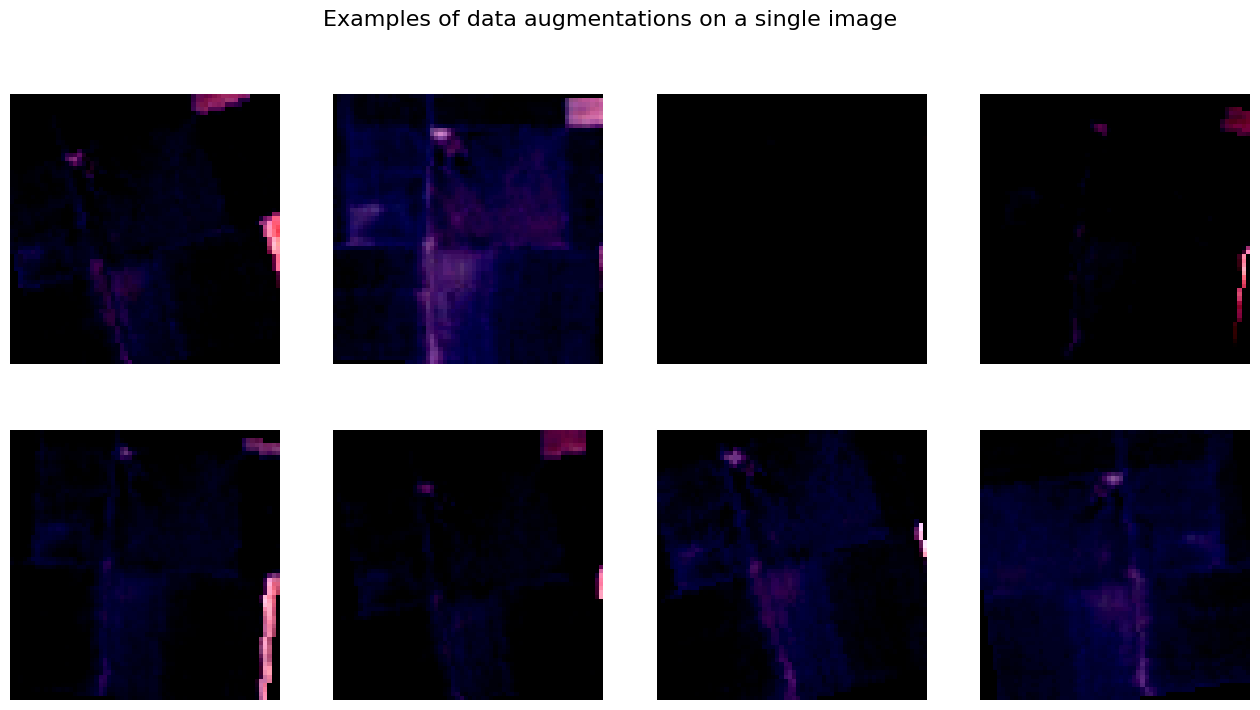

In [24]:
img, _ = eurosat_data[0]
pil_img = transforms.ToPILImage()(img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    aug_img = train_transform(pil_img)
    axes[i].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")

plt.suptitle("Examples of data augmentations on a single image", fontsize=16)
plt.show()